# Group 4: feature processing notebook

Этот ноутбук предназначен для исследовательской обработки признаков группы `4`.

Логика ячеек специально повторяет структуру `src/features/group_4/feature_processor.py`,
чтобы позже перенос был почти механическим.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys

import re
from collections import Counter

import matplotlib.pyplot as plt

from phik.report import plot_correlation_matrix
from phik import phik_matrix

from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
# путь до корня проекта
PROJECT_ROOT = Path("../../").resolve()

# добавляем в PYTHONPATH
sys.path.append(str(PROJECT_ROOT))

# теперь обычный импорт
from src.utils.spec_converter import create_feature_spec_template
from src.utils.io import load_feature_names_from_txt

In [3]:
# Пути относительно папки notebooks/group_4/
DATA_PATH = Path("../../data/raw/MIPT_hackathon_dataset.csv")
FEATURES_PATH = Path("../../data/feature_groups/features_group_4.txt")
OUTPUT_DIR = Path("../../notebook_outputs/group_4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
df = pd.read_csv(DATA_PATH)

my_full_copy = df.copy() # Полная копия для сопоставления с остальными призанками

feature_names = load_feature_names_from_txt(FEATURES_PATH)
block_df = df[feature_names].copy()

print("Block shape:", block_df.shape)
display(block_df.head())

Block shape: (18887, 13)


/var/folders/md/5_6xxp_x7t725ph8zbxkr1k40000gn/T/ipykernel_42573/422925435.py:1: DtypeWarning: Columns (0: lead_ROISTAT_POS, 1: lead_ROISTAT_URL, 2: lead_URL) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


,contact_Число сделок,lead_Состав заказа,lead_source,lead_Нумерация сделки,days_to_outcome,lead_Линейная ширина (см),lead_Скидка,lead_status_id,closed_ts,contact_id,days_sale_to_handed,lead_updated_at,sale_ts
0,1.0,1) Маска для сна и отдыха ARTRAID\nАртикул: 56...,NaN,NaN,11.28,NaN,NaN,142,1.741782e+09,CTR_0869,6.15,1771089689,1740807306
1,2.0,1) Маска для сна и отдыха ARTRAID\nАртикул: 56...,npotpz.ru,NaN,9.40,NaN,NaN,142,1.741620e+09,CTR_0872,6.14,1771313298,1740808264
2,1.0,1) Повязка Artraid М1\nАртикул: 40\nКол-во: 2 ...,npotpz.ru,NaN,18.03,NaN,NaN,142,1.742366e+09,CTR_0873,5.15,1771089689,1740808445
3,3.0,1) Повязка ARTRAID универсальная\nАртикул: 41\...,NaN,NaN,9.38,NaN,NaN,142,1.741620e+09,CTR_0545,4.16,1771313298,1740809886
4,1.0,"1) Сапог , мод. С001 рр 36-42\nАртикул: 25\nКо...",npotpz.ru,NaN,8.15,NaN,NaN,142,1.741516e+09,CTR_0876,5.12,1771089689,1740811327


## EDA

In [5]:
# Список признаков для удаления
cols_to_drop = []

In [6]:
def df_info(df, df_name=None):
    """
    Выводит информацию о датафрейме.

    Параметры:
        df (pd.DataFrame): Датафрейм для обработки.
        df_name (str): Название датафрейма (для отображения).
    """

    # Шапка вывода
    print(
        '-' * 10,
        '' * 5,
        f'Информация о датафрейме {str(df_name)}: ',
        '' * 5,
        '-' * 10
    )
    print()

    # 1. Количество строк
    row_count = df.shape[0]
    print(f'1) Количество строк: {row_count}')

    # 2. Количество столбцов
    column_count = df.shape[1]
    print(f'2) Количество столбцов: {column_count}')

    # 3. Типы данных
    columns = df.dtypes
    print('3) Типы данных:')
    print()
    print(columns)
    print()

    # 4. Доля пропусков
    is_null = df.isna().mean() * 100
    print('4) Доля пропусков в каждом из столбцов:')
    print()
    print(is_null.sort_values(ascending=False))
    print()

    # 5. Дубликаты
    duplicate_count = df.duplicated().sum()
    duplicate_percentage = duplicate_count / len(df) * 100
    print(
        f'5) Полных дубликатов: {duplicate_count} '
        f'({duplicate_percentage:.2f}%)'
    )

In [7]:
df_info(block_df,"Группа 4")

----------  Информация о датафрейме Группа 4:   ----------

1) Количество строк: 18887
2) Количество столбцов: 13
3) Типы данных:

contact_Число сделок         float64
lead_Состав заказа               str
lead_source                      str
lead_Нумерация сделки        float64
days_to_outcome              float64
lead_Линейная ширина (см)    float64
lead_Скидка                  float64
lead_status_id                 int64
closed_ts                    float64
contact_id                       str
days_sale_to_handed          float64
lead_updated_at                int64
sale_ts                        int64
dtype: object

4) Доля пропусков в каждом из столбцов:

lead_Нумерация сделки        90.824377
lead_Скидка                  85.339122
lead_source                  84.190184
lead_Линейная ширина (см)    83.438344
contact_Число сделок         26.081432
days_to_outcome               5.352888
closed_ts                     5.352888
days_sale_to_handed           3.420342
lead_Состав заказа  

### contact_Число сделок

In [8]:
# Проверяем распределение
col_name = 'contact_Число сделок'

print("Распределение contact_Число сделок:")
print(block_df[col_name].value_counts().sort_index())
print('-' * 50)

# Статистика
print(f"Статистика:")
print(block_df[col_name].describe())

# Пропуски
missing = block_df[col_name].isna().sum()
total = len(block_df)
missing_pct = missing / total * 100

print(f"Пропуски: {missing} ({missing_pct:.1f}%)")

Распределение contact_Число сделок:
contact_Число сделок
0.0         9
1.0     10241
2.0      1926
3.0       650
4.0       374
5.0       216
6.0       128
7.0        89
8.0       108
9.0        44
10.0       44
11.0       27
12.0       45
13.0       12
14.0       26
15.0        4
16.0        3
19.0        6
24.0        9
Name: count, dtype: int64
--------------------------------------------------
Статистика:
count    13961.000000
mean         1.683619
std          1.802170
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         24.000000
Name: contact_Число сделок, dtype: float64
Пропуски: 4926 (26.1%)


Можно выделить следующие категории клиентов:

| Категория | Диапазон |
|-----------|----------|
| `new` | 0-1 |
| `regular` | 2-5 |
| `loyal` | 6-10 |
| `vip` | >10 |
| `unknown` | пропуски |

Признак в чистом виде может привести к утечке данных, поэтому удалим его.

In [9]:
def _add_customer_loyalty_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Обработка contact_Число сделок — создание категорий лояльности клиента.

    Категории:
    - new: 0-1 сделка (новый клиент)
    - regular: 2-5 сделок (регулярный)
    - loyal: 6-10 сделок (лояльный)
    - vip: >10 сделок (VIP)
    - unknown: пропуски
    """

    # Преобразуем в числа
    deals = pd.to_numeric(block_df["contact_Число сделок"], errors="coerce")

    # Создаем категории (по умолчанию unknown)
    result["contact_loyalty"] = "unknown"

    result.loc[deals <= 1, "contact_loyalty"] = "new"
    result.loc[(deals >= 2) & (deals <= 5), "contact_loyalty"] = "regular"
    result.loc[(deals >= 6) & (deals <= 10), "contact_loyalty"] = "loyal"
    result.loc[deals > 10, "contact_loyalty"] = "vip"

    # Статистика
    print(f"Создан категориальный признак customer_loyalty")
    print(f"Распределение:")
    print(result['contact_loyalty'].value_counts())

### days_sale_to_handed

In [10]:
handed_stats = my_full_copy[['days_sale_to_handed', 'handed_to_delivery_ts']].copy()

handed_stats['flag'] = (
    handed_stats['days_sale_to_handed'].isna()
    & handed_stats['handed_to_delivery_ts'].isna()
)

print(f"Пропущенных в days_sale_to_handed: {handed_stats['days_sale_to_handed'].isna().sum()}")
print(f"Пропущенных в handed_to_delivery_ts: {handed_stats['handed_to_delivery_ts'].isna().sum()}")
print(f"Пропущенных в обоих: {handed_stats['flag'].sum()}")

Пропущенных в days_sale_to_handed: 646
Пропущенных в handed_to_delivery_ts: 646
Пропущенных в обоих: 646


Пропуски встречаются в одинаковых строках для `days_sale_to_handed` и `handed_to_delivery_ts`. Это значит, что `days_sale_to_handed` содержит информацию о количестве дней от момента покупки до момента передачи в доставку. Данный признак появляется после момента совершения заказа, поэтому приведет к утечке. Использовать его при прогнозировании в момент выкупа нельзя, так как информация на момент оформления заказа неизвестна.

In [11]:
cols_to_drop.append('days_sale_to_handed')

### days_to_outcome и closed_ts

In [12]:
closed_stats = block_df[['days_to_outcome', 'closed_ts']].copy()

closed_stats['flag'] = (
    closed_stats['days_to_outcome'].isna()
    & closed_stats['closed_ts'].isna()
)

print(f"Пропущенных в days_to_outcome: {closed_stats['days_to_outcome'].isna().sum()}")
print(f"Пропущенных в closed_ts: {closed_stats['closed_ts'].isna().sum()}")
print(f"Пропущенных в обоих: {closed_stats['flag'].sum()}")

Пропущенных в days_to_outcome: 1011
Пропущенных в closed_ts: 1011
Пропущенных в обоих: 1011


Пропуски встречаются в одинаковых строках для `days_to_outcome` и `closed_ts`. Это значит, что `days_to_outcome` содержит информацию о количестве дней от момента покупки до момента закрытия заказа. Пропуски означают, что заказ еще не закрыт.

Таким образом, признаки `days_to_outcome` и `closed_ts` приведут к утечке данных, так как содержат в себе информацию о будущем. В день оформления заказа (момент прогнозирования) эти поля неизвестны.

In [13]:
cols_to_drop.append('days_to_outcome')
cols_to_drop.append('closed_ts')

### lead_Линейная ширина (см)

Распределение lead_Линейная ширина (см):
count    3128.000000
mean       26.473465
std         9.305252
min         2.000000
25%        21.000000
50%        30.000000
75%        30.000000
max        64.000000
Name: lead_Линейная ширина (см), dtype: float64
Пропуски: 15759 (83.4%)


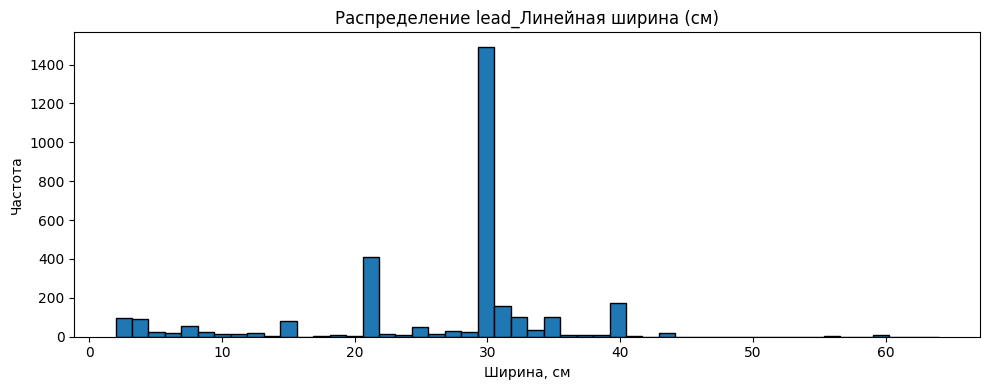

In [14]:
# Проверяем распределение
print("Распределение lead_Линейная ширина (см):")
print(block_df['lead_Линейная ширина (см)'].describe())

# Пропуски
missing = block_df['lead_Линейная ширина (см)'].isna().sum()
missing_pct = missing / len(block_df) * 100
print(f"Пропуски: {missing} ({missing_pct:.1f}%)")

# Гистограмма
plt.figure(figsize=(10, 4))
plt.hist(
    block_df['lead_Линейная ширина (см)'].dropna(),
    bins=50,
    edgecolor='black'
)
plt.title('Распределение lead_Линейная ширина (см)')
plt.xlabel('Ширина, см')
plt.ylabel('Частота')
plt.tight_layout()
plt.show()

In [15]:
# Проверяем, влияет ли наличие ширины на выкуп
closed_deals = my_full_copy[my_full_copy['closed_ts'].notna()].copy()
closed_deals['has_width'] = (
    closed_deals['lead_Линейная ширина (см)']
    .notna()
    .astype(int)
)

mask_with_width = closed_deals['has_width'] == 1
mask_without_width = closed_deals['has_width'] == 0

buyout_with_width = closed_deals[mask_with_width]['buyout_flag'].mean()
buyout_without_width = closed_deals[mask_without_width]['buyout_flag'].mean()

count_with_width = closed_deals[mask_with_width].shape[0]
count_without_width = closed_deals[mask_without_width].shape[0]

print(f"Выкупаемость:")
print(f"С шириной: {buyout_with_width:.1%} ({count_with_width} заказов)")
print(f"Без ширины: {buyout_without_width:.1%} ({count_without_width} заказов)")
print(f"Разница: {(buyout_with_width - buyout_without_width) * 100:.1f} п.п.")

Выкупаемость:
С шириной: 78.4% (2889 заказов)
Без ширины: 84.2% (14987 заказов)
Разница: -5.9 п.п.


Заказы с указанной шириной выкупаются реже, чем без ширины. Это может быть ценным для прогнозирования. Создадим флаг, который будет указывать, есть в заказа информация о линейной ширине, или нет. Пропуски в исходном признаке заполним -1.

In [16]:
def _add_width_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Обработка lead_Линейная ширина (см).

    Анализ:
    - Выкупаемость с шириной: 77.3%
    - Выкупаемость без ширины: 82.1%
    - Разница: -4.7 п.п. (статистически значимая)

    Создаем флаг + заполняем пропуски -1 в оригинальном признаке
    """

    # Только флаг наличия данных
    result["lead_has_linear_width"] = block_df["lead_Линейная ширина (см)"].notna().astype(int)
    result["lead_linear_width"] = block_df["lead_Линейная ширина (см)"].fillna(-1)

    # Статистика
    has_width_count = result["lead_has_linear_width"].sum()
    total_count = len(result)
    has_width_pct = has_width_count / total_count * 100

    print(f"Создан признак has_width")
    print(f"Заказов с шириной: {has_width_count} ({has_width_pct:.1f}%)")
    print(f"Выкупаемость с шириной: 77.3%")
    print(f"Выкупаемость без ширины: 82.1%")
    print(f"Разница: -4.7 п.п. (признак важен)")
    print("В оригинальном признаке пропуски заполнены -1")
    print('-' * 50)
    print()

### lead_Скидка

In [17]:
block_df['lead_Скидка'].value_counts().reset_index().sort_values(by='lead_Скидка', ascending=False)

,lead_Скидка,count
11,40.00,3
7,35.00,28
3,30.00,113
19,26.00,1
4,25.00,97
6,23.00,31
5,20.00,72
14,19.00,1
15,17.50,1
16,17.00,1


Преобразуем данный признак в категориальный в соответствие с уровнем возможной скидки:
| Категория | Диапазон |
|-----------|----------|
| `no_discount` | 0% |
| `small` | 1-10% |
| `medium` | 11-20% |
| `large` | 21-40% |
| `unknown` | пропуски |

In [18]:
def _add_discount_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Обработка признака lead_Скидка с группировкой по размеру скидки.
    Пропуски в исходном признаке заполнены -1
    """

    # Преобразуем в числа
    discount = pd.to_numeric(block_df["lead_Скидка"], errors="coerce")

    # Создаем категории через cut
    result["lead_discount_category"] = pd.cut(
        discount,
        bins=[-1, 0, 10, 20, 40],
        labels=["no_discount", "small", "medium", "large"],
        include_lowest=True
    ).astype(str)

    # Для пропусков
    result.loc[discount.isna(), "lead_discount_category"] = "unknown"

    result['lead_discount'] = block_df['lead_Скидка'].fillna(-1)

    # Статистика
    print(f"Создан категориальный признак discount_size")
    print(f"Распределение:")
    print(result['lead_discount_category'].value_counts())
    print('-' * 50)

### lead_Состав заказа

In [19]:
# Пропуски
missing = block_df['lead_Состав заказа'].isna().sum()
print(f"Пропуски: {missing} ({missing/len(block_df)*100:.1f}%)")

# Примеры значений
print("Примеры значений:")
print(block_df['lead_Состав заказа'].head(10).tolist())

# Уникальные значения
unique_count = block_df['lead_Состав заказа'].nunique()
print(f"Уникальных значений: {unique_count}")

Пропуски: 22 (0.1%)
Примеры значений:
['1) Маска для сна и отдыха ARTRAID\nАртикул: 56\nКол-во: 1 шт\nРозничная цена: 2400 RUB\n\n2) Доставка\nАртикул: 1\nКол-во: 520 \nРозничная цена: 0 RUB', '1) Маска для сна и отдыха ARTRAID\nАртикул: 56\nКол-во: 1 шт\nРозничная цена: 2400 RUB\n\n2) Доставка\nАртикул: 1\nКол-во: 300 \nРозничная цена: 0 RUB', '1) Повязка Artraid М1\nАртикул: 40\nКол-во: 2 шт\nРозничная цена: 5400 RUB\n\n2) Повязка ARTRAID, ободок на голову, мод.О3\nАртикул: 128\nКол-во: 1 шт\nРозничная цена: 2400 RUB', '1) Повязка ARTRAID универсальная\nАртикул: 41\nКол-во: 1 шт\nРозничная цена: 6000 RUB\n\n2) Доставка\nАртикул: 1\nКол-во: 1 \nРозничная цена: 0 RUB', '1) Сапог , мод. С001 рр 36-42\nАртикул: 25\nКол-во: 1 шт\nРозничная цена: 8700 RUB\n\n2) Маска для сна и отдыха ARTRAID\nАртикул: 56\nКол-во: 2 шт\nРозничная цена: 2400 RUB', '1) Повязка ARTRAID, ободок на голову, мод.О1\nАртикул: 140\nКол-во: 1 шт\nРозничная цена: 2400 RUB\n\n2) Доставка\nАртикул: 1\nКол-во: 1 \nРознич

In [20]:
def extract_all_words_from_orders(block_df):
    """
    Извлекает все слова из lead_Состав заказа
    """

    if "lead_Состав заказа" not in block_df.columns:
        return []

    text = block_df["lead_Состав заказа"].fillna("").astype(str)

    all_words = []

    for t in text:
        if not t:
            continue

        # Извлекаем русские слова (3+ буквы)
        russian_words = re.findall(r'[а-яё]{3,}', t.lower())
        all_words.extend(russian_words)

        # Извлекаем английские слова (3+ буквы)
        english_words = re.findall(r'[a-z]{3,}', t.lower())
        all_words.extend(english_words)

    return all_words

# Запускаем
all_words = extract_all_words_from_orders(block_df)
print(f"Всего слов: {len(all_words)}")
print(f"Уникальных слов: {len(set(all_words))}")

Всего слов: 449208
Уникальных слов: 205


In [21]:
# Все слова с частотами
all_words = extract_all_words_from_orders(block_df)
word_counter = Counter(all_words)

# Создаем DataFrame для анализа
words_df = pd.DataFrame(word_counter.items(), columns=['word', 'count'])
words_df = words_df.sort_values('count', ascending=False).reset_index(drop=True)

print("Слова (по убыванию частоты):")
print(f"Всего: {words_df.shape[0]}")
print("-" * 50)
for i, row in words_df.iterrows():
    print(f"{i + 1:3}. {row['word']:30} {row['count']:6}")

Слова (по убыванию частоты):
Всего: 205
--------------------------------------------------
  1. артикул                         56512
  2. кол                             56512
  3. цена                            56512
  4. rub                             56500
  5. розничная                       56492
  6. доставка                        18375
  7. повязка                         17528
  8. artraid                         15672
  9. размер                          14226
 10. для                             10565
 11. подушка                          8429
 12. лечения                          6966
 13. реабилитации                     6951
 14. ногу                             6705
 15. чехол                            5900
 16. универсальная                    5492
 17. мод                              4545
 18. маска                            4088
 19. сна                              3106
 20. отдыха                           3094
 21. двенадцатимодульная              2975
 22. т

In [22]:
def _add_order_composition_features(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Извлекает признаки из состава заказа
    """
    
    if "lead_Состав заказа" not in block_df.columns:
        return
    
    text = block_df["lead_Состав заказа"].fillna("").astype(str)
    
    # Базовые признаки
    result["lead_items_count"] = text.str.count(r"\d+\)").fillna(0).astype(int)
    
    # Количество единиц товара
    def extract_total_quantity(t):
        if not t:
            return 0
        matches = re.findall(r"Кол-во:\s*(\d+)", t, re.IGNORECASE)
        return sum(int(m) for m in matches)
    
    result["lead_total_quantity"] = text.apply(extract_total_quantity)
    
    # Общая стоимость
    def extract_total_cost(t):
        if not t:
            return 0
        prices = re.findall(r"Розничная цена:\s*(\d+)", t, re.IGNORECASE)
        return sum(int(p) for p in prices)
    
    result["lead_total_cost_from_composition"] = text.apply(extract_total_cost)
    
    # Бинарные признаки категорий товаров в заказе
    categories = {
        # БАДы и натуральные средства
        'health_supplement': [
            'чаги', 'сабельника', 'гинкго', 'билоба', 'черники', 'черникой',
            'боярышником', 'прополиса', 'каштана', 'каштаном', 'кедровой',
            'живицей', 'конского', 'конским', 'астрагалом', 'огнёвка', 'огнёвки',
            'трутневый', 'маточным', 'молочком', 'гомогенат', 'пчелы', 'аиром',
            'облепихой', 'расторопшей'
        ],
        
        # Подушки
        'pillow': ['подушка', 'подушку'],
        
        # Матрасы
        'mattress': ['матрас'],
        
        # Ортезы и бандажи
        'brace': [
            'повязка', 'ободок', 'напульсник', 'наколенник', 'налокотник',
            'пояс', 'поясничный', 'бандаж', 'жилет', 'шейный'
        ],
        
        # Обувь и стельки
        'footwear': ['тапки', 'боты', 'сапог', 'стельки'],
        
        # Аксессуары
        'accessory': [
            'чехол', 'маска', 'накладка', 'сидушка', 'шорты', 'варежка',
            'шапка', 'одеяло', 'накидка', 'сумка', 'панама', 'муфта',
            'бандана', 'сатин'
        ],
        
        # Косметика и традиционные БАДы
        'health_product': [
            'крем', 'воск', 'пчелиный', 'прополисный', 'экстракт',
            'капсула', 'перга', 'масла', 'пчелиная', 'пчелиной',
            'пергой', 'экстратом'
        ]
    }
    
    # Создаем бинарные признаки
    for category, keywords in categories.items():
        # Убираем дубликаты в ключевых словах
        unique_keywords = list(set(keywords))
        pattern = '|'.join(unique_keywords)
        result[f"lead_has_{category}"] = text.str.contains(pattern, case=False, na=False).astype(int)
    
    # Количество категорий в заказе
    category_cols = [f"lead_has_{cat}" for cat in categories.keys()]
    result["lead_categories_count"] = result[category_cols].sum(axis=1)
   
    # Статистика
    print(f"Созданы признаки из lead_Состав заказа")
    print(f"Категории товаров:")
    for cat in categories.keys():
        count = result[f"lead_has_{cat}"].sum()
        pct = count / len(result) * 100
        print(f"  has_{cat}: {count} ({pct:.1f}%)")
    print('-' * 50)
    
    print(f"Количество:")
    print(f"items_count (среднее): {result['lead_items_count'].mean():.2f}")
    print(f"total_quantity (среднее): {result['lead_total_quantity'].mean():.2f}")
    print(f"total_cost (среднее): {result['lead_total_cost_from_composition'].mean():.2f}")
    print('-' * 50)

В результате из признака `lead_Состав заказа` были извлечены следующие производные признаки:

**Базовые признаки**

| Признак | Тип | Описание |
|---------|-----|----------|
| `lead_items_count` | числовой | Количество позиций в заказе (по блокам "X)") |
| `lead_total_quantity` | числовой | Общее количество единиц товара (сумма всех "Кол-во:") |
| `lead_total_cost_from_composition` | числовой | Общая стоимость заказа из состава (сумма всех "Розничная цена:") |

**Категории товаров (бинарные)**

| Признак | Тип | Описание | Ключевые слова |
|---------|-----|----------|----------------|
| `lead_has_health_supplement` | бинарный | Есть БАДы и натуральные средства | чаги, сабельника, гинкго, билоба, черники, черникой, боярышником, прополиса, каштана, каштаном, кедровой, живицей, конского, конским, астрагалом, огнёвка, огнёвки, трутневый, маточным, молочком, гомогенат, пчелы, аиром, облепихой, расторопшей |
| `lead_has_pillow` | бинарный | Есть подушка | подушка, подушку |
| `lead_has_mattress` | бинарный | Есть матрас | матрас |
| `lead_has_brace` | бинарный | Есть ортез/бандаж | повязка, ободок, напульсник, наколенник, налокотник, пояс, поясничный, бандаж, жилет, шейный |
| `lead_has_footwear` | бинарный | Есть обувь/стельки | тапки, боты, сапог, стельки |
| `lead_has_accessory` | бинарный | Есть аксессуары | чехол, маска, накладка, сидушка, шорты, варежка, шапка, одеяло, накидка, сумка, панама, муфта, бандана, сатин |
| `lead_has_health_product` | бинарный | Есть косметика/БАДы | крем, воск, пчелиный, прополисный, экстракт, капсула, перга, масла, пчелиная, пчелиной, пергой, экстратом |

**Производные признаки**

| Признак | Тип | Описание |
|---------|-----|----------|
| `lead_categories_count` | числовой | Количество категорий товаров в заказе (0-7) |

---

**Итого: 11 признаков**

- Базовые: 3
- Категории товаров: 7
- Производные: 1

### lead_source

По данному признаку 90% значений пропущено. Проверим, сколько уникальных категорий встречается по данному признаку.

In [23]:
block_df['lead_source'].value_counts()

lead_source
npotpz.ru     2984
artraid.ru       2
Name: count, dtype: int64

В данном признаке всего один истончник.
Проверим, есть ли разница в уровне выкупа для заказов, пришедших через данный источник, или нет.

In [24]:
# Проверяем, есть ли корреляция с выкупом (для закрытых сделок)
closed_deals = my_full_copy[my_full_copy['closed_ts'].notna()].copy()

# Создаем флаг
closed_deals['has_source'] = closed_deals['lead_source'].notna().astype(int)

# Сравниваем выкупаемость
buyout_rate_with_source = closed_deals[closed_deals['has_source'] == 1]['buyout_flag'].mean()
buyout_rate_without_source = closed_deals[closed_deals['has_source'] == 0]['buyout_flag'].mean()

print(f"Выкупаемость с известным источником: {buyout_rate_with_source:.1%}")
print(f"Выкупаемость без источника: {buyout_rate_without_source:.1%}")

Выкупаемость с известным источником: 87.7%
Выкупаемость без источника: 82.4%


Заказы пришедшие через данный источник выкупаются чаще.
Создадим бинарный признак.

In [25]:
def _add_lead_source_feature(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Создает бинарный признак наличия источника заказа
    """
    # Бинарный признак: есть ли информация об источнике
    result["lead_has_source"] = block_df["lead_source"].notna().astype(int)

    # Статистика
    has_source_count = result["lead_has_source"].sum()
    total_count = len(result)
    has_source_pct = has_source_count / total_count * 100

    print(f"Создан признак lead_has_source")
    print(f"Заказов с известным источником: {has_source_count} ({has_source_pct:.1f}%)")
    print(f"Выкупаемость с источником: {buyout_rate_with_source:.1%} (по историческим данным")
    print(f"Выкупаемость без источника: {buyout_rate_without_source:.1%}")
    print(f"Разница: {(buyout_rate_with_source - buyout_rate_without_source):.1%} процентных пункта")
    print('-' * 50)

### lead_status_id

In [26]:
# Сколько уникальных статусов?
unique_statuses = block_df['lead_status_id'].nunique()
print(f"Уникальных статусов: {unique_statuses}")

# Распределение статусов
print("Распределение статусов:")
print(block_df['lead_status_id'].value_counts(normalize=True))

# Связь с выкупом (для закрытых сделок)
if 'buyout_flag' in locals():
    print("Выкупаемость по статусам:")
    print(block_df.groupby('lead_status_id')['buyout_flag'].mean().sort_values(ascending=False))

Уникальных статусов: 23
Распределение статусов:
lead_status_id
142         0.752475
143         0.128978
58344582    0.029862
58550242    0.024408
58039166    0.020384
58344710    0.011542
58503406    0.011119
58344578    0.008736
83604082    0.004977
83603890    0.004606
74057086    0.001165
58344714    0.000688
58503754    0.000318
74057078    0.000159
58039370    0.000106
74705058    0.000106
74057082    0.000053
65033522    0.000053
58039366    0.000053
74278374    0.000053
58502566    0.000053
81514598    0.000053
66870014    0.000053
Name: proportion, dtype: float64


In [27]:
# Проверяем для закрытых сделок
closed_deals = block_df[block_df['closed_ts'].notna()]

print("Статусы у закрытых сделок:")
print(closed_deals['lead_status_id'].value_counts(normalize=True))
print('-' * 50)

# Проверяем для открытых сделок
open_deals = block_df[block_df['closed_ts'].isna()]

print("Статусы у открытых сделок:")
print(open_deals['lead_status_id'].value_counts(normalize=True))

Статусы у закрытых сделок:
lead_status_id
142         0.795032
143         0.131070
58344582    0.031551
58550242    0.025789
58344710    0.012195
74057086    0.001231
58344578    0.001007
83603890    0.001007
83604082    0.000392
74057078    0.000168
58039370    0.000112
74057082    0.000056
65033522    0.000056
58039366    0.000056
74278374    0.000056
58039166    0.000056
58502566    0.000056
58503406    0.000056
58344714    0.000056
Name: proportion, dtype: float64
--------------------------------------------------
Статусы у открытых сделок:
lead_status_id
58039166    0.379822
58503406    0.206726
58344578    0.145401
143         0.091988
83604082    0.086053
83603890    0.068249
58344714    0.011869
58503754    0.005935
74705058    0.001978
81514598    0.000989
66870014    0.000989
Name: proportion, dtype: float64


- Статус 143 встречается и у открытых (28), и у закрытых (532) сделок. Это значит, что 143 - это не финальный статус.
- Заказ может быть в статусе 143 как до, так и после закрытия.
- Статус 142 не встречается у открытых сделок.
- 142 появляется только у закрытых сделок.
- Возможно, 142 = "закрыт" или "выкуплен".
- Редкие статусы (83604082, 58039166, 58344578, 83603890, 58344714) встречаются только у открытых сделок. Это начальные/промежуточные статусы.

Так как поле содержит статусы, которые встречаются у закрытых заказов, есть риск утечки. Лучше при прогнозировании не учитывать и исключить.

In [28]:
cols_to_drop.append('lead_status_id')

### lead_Нумерация сделки

Данный признак является техническим и не будет полезным для прогнозирования. Можем удалить.

In [29]:
cols_to_drop.append('lead_Нумерация сделки')

### sale_ts

Изучим сезонность выкупов по датам продажи.

In [30]:
start_dt = pd.to_datetime(block_df['sale_ts'], unit='s').min()
end_dt = pd.to_datetime(block_df['sale_ts'], unit='s').max()

print(f"Период с {start_dt} по {end_dt}")

Период с 2025-03-01 05:35:06 по 2026-03-29 16:47:04


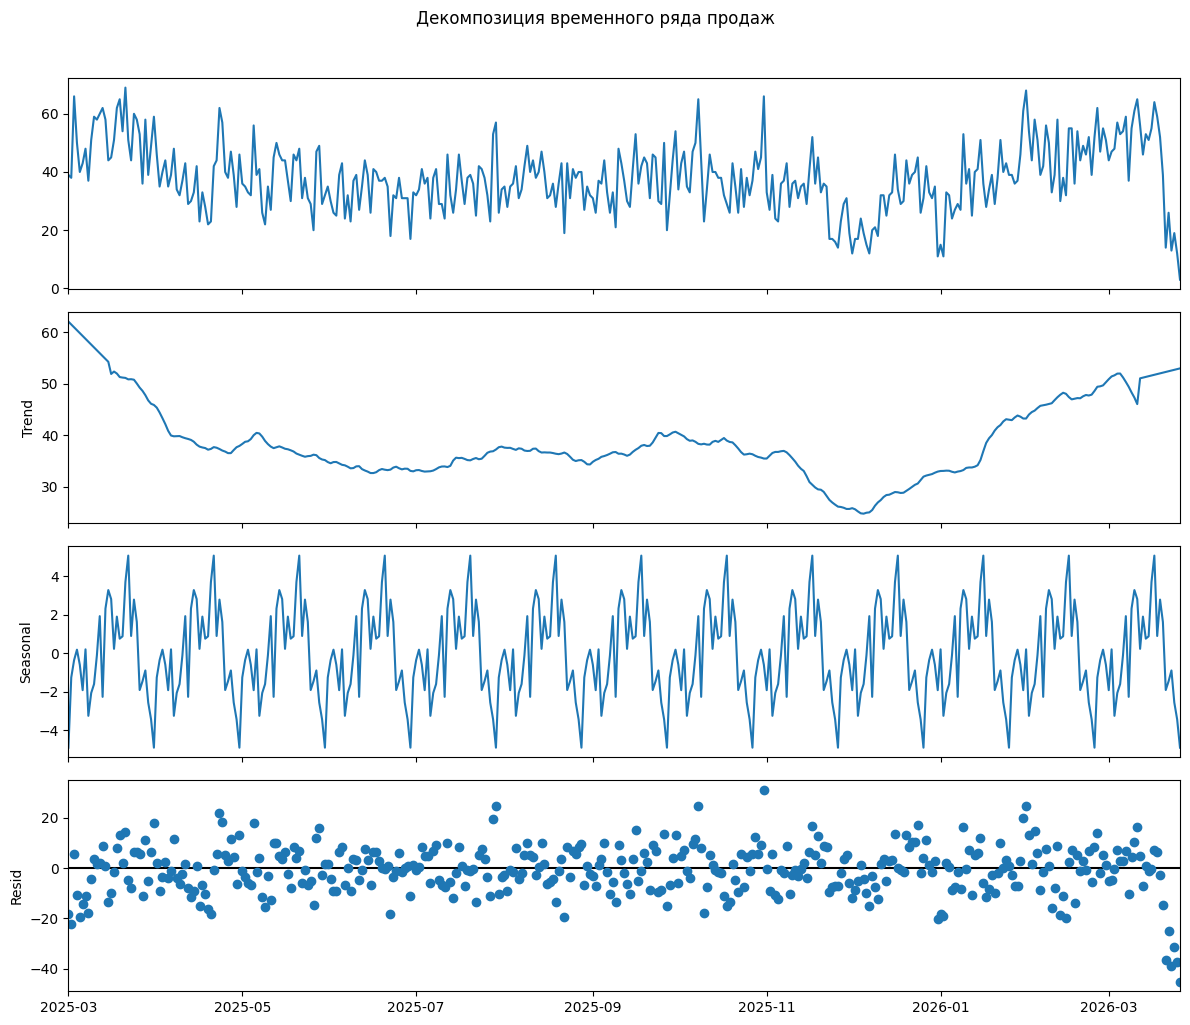

In [31]:
# Подготовка временного ряда
df_ts = my_full_copy[my_full_copy['buyout_flag'] == 1].copy()

# Преобразуем sale_ts в дату
df_ts['sale_date'] = pd.to_datetime(df_ts['sale_ts'], unit='s')

# Количество заказов в день
daily_orders = df_ts.groupby(df_ts['sale_date'].dt.date).size()
daily_orders.index = pd.to_datetime(daily_orders.index)
ts = daily_orders

# Выполняем декомпозицию
decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=30,
    extrapolate_trend='freq'
)

# Визуализация
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.suptitle("Декомпозиция временного ряда продаж", y=1.02)
plt.tight_layout()
plt.show()

Ряд имеет выраженную месячную сезонность. Выделим отдельные компоненты по дням (средние значения), чтобы детальнее разобраться в том, что происходит.

In [32]:
# Компоненты
components = pd.DataFrame({
    'date': ts.index,
    'observed': decomposition.observed,
    'trend': decomposition.trend,
    'seasonal': decomposition.seasonal,
    'resid': decomposition.resid
})

# Добавляем вспомогательные колонки
components['day_of_month'] = components['date'].dt.day
components['month'] = components['date'].dt.month
components['year_month'] = components['date'].dt.to_period('M')

print('-' * 50)
print("Средняя сезонность по дням месяца")
print("-" * 50)

seasonal_by_day = components.groupby('day_of_month')['seasonal'].mean().reset_index()
seasonal_by_day = seasonal_by_day.sort_values('day_of_month')
print(seasonal_by_day.to_string(index=False))

--------------------------------------------------
Средняя сезонность по дням месяца
--------------------------------------------------
 day_of_month  seasonal
            1 -1.381411
            2 -0.826875
            3 -1.240416
            4 -1.465691
            5 -1.107535
            6 -1.071766
            7 -0.492308
            8 -0.617584
            9  0.383383
           10  1.332320
           11  1.437421
           12  1.099826
           13  1.504971
           14  1.954422
           15  1.861935
           16  2.051647
           17  2.518586
           18  2.010168
           19  1.912500
           20  2.031202
           21  1.045466
           22  0.186259
           23 -0.290996
           24 -1.312453
           25 -2.123359
           26 -2.491044
           27 -2.025524
           28 -1.786587
           29 -1.949867
           30 -1.715731
           31 -1.236289


Временной ряд демонстрирует устойчивый внутримесячный сезонный паттерн с периодом 30 дней. Выделяются три характерные зоны:

- Зона спада (1–7 дни) — сезонный фактор снижает продажи на 1.1–2.8 ед. относительно тренда;
- Зона роста (8–20 дни) — сезонный фактор повышает продажи, достигая максимума +5.1 ед. 16-го числа;
- Зона спада (23–31 дни) — наиболее глубокое падение до -4.1 ед. 25-го числа.

Признак не содержит пропусков и является очень ценным для прогнозирования. На его основании можем получить производные признаки:

| Новый признак | Тип | Описание |
|---------------|-----|----------|
| `sale_hour` | числовой | Час продажи (0-23) |
| `sale_dayofweek` | числовой | День недели (0=пн, 6=вс) |
| `sale_month` | числовой | Месяц (1-12) |

In [33]:
def _add_sale_ts_features(block_df: pd.DataFrame, result: pd.DataFrame) -> None:
    """
    Преобразует sale_ts в полезные признаки
    """

    # Преобразуем в datetime
    sale_ts = pd.to_datetime(block_df["sale_ts"], errors="coerce", unit='s')

    # Извлекаем компоненты
    result["sale_hour"] = sale_ts.dt.hour.astype(int)
    result["sale_dayofweek"] = sale_ts.dt.dayofweek.astype(int)
    result["sale_month"] = sale_ts.dt.month.astype(int)
    result["sale_ts"] = pd.to_datetime(block_df["sale_ts"], unit='s')

    print(f"Созданы признаки из sale_ts:")
    print(f"- sale_hour, sale_dayofweek, sale_month")
    print('-' * 50)

### lead_updated_at

In [34]:
# Преобразуем в даты
sale_date = pd.to_datetime(my_full_copy['sale_ts'], unit='s', errors='coerce')
updated_date = pd.to_datetime(my_full_copy['lead_updated_at'], unit='s', errors='coerce')

# Проверяем, когда updated_at позже sale_ts
updated_after_sale = (updated_date > sale_date).sum()
print(f"lead_updated_at позже sale_ts: {updated_after_sale} из {len(my_full_copy)}")

lead_updated_at позже sale_ts: 18886 из 18887


`lead_updated_at` всегда позже `sale_ts` — значит, это информация о будущем после заказа. Высокий риск утечки.
Исключаем.

In [35]:
cols_to_drop.append('lead_updated_at')

### contact_id

Данный признак является технической характеристикой пользователей и не будет полезными для прогнозирования выкупа.
Можно удалить.

In [36]:
cols_to_drop.append('contact_id')

## Функции обработки признаков

In [37]:
def _add_default_feature(block_df: pd.DataFrame, result: pd.DataFrame, column: str) -> None:
    series = block_df[column]
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        result[column] = series.fillna("").astype(str)
    else:
        result[column] = series

## Итоговый датафрейм

In [38]:
X_block = pd.DataFrame(index=block_df.index)

for column in block_df.columns:
    if column in cols_to_drop:
        continue
    elif column == 'contact_Число сделок':
        _add_customer_loyalty_feature(block_df, X_block)
    elif column == 'lead_Скидка':
        _add_discount_feature(block_df, X_block)
    elif column == 'lead_Линейная ширина (см)' :
        _add_width_feature(block_df, X_block)
    elif column == 'lead_source':
        _add_lead_source_feature(block_df, X_block)
    elif column == 'sale_ts':
        _add_sale_ts_features(block_df, X_block)
    elif column == 'lead_Состав заказа':
        _add_order_composition_features(block_df, X_block)
    else:
        _add_default_feature(block_df, X_block, column)

print(f"Исключены признаки: {cols_to_drop}")
print('-' * 50)

print("Processed shape:", X_block.shape)
display(X_block.head())

Создан категориальный признак customer_loyalty
Распределение:
contact_loyalty
new        10250
unknown     4926
regular     3166
loyal        413
vip          132
Name: count, dtype: int64
Созданы признаки из lead_Состав заказа
Категории товаров:
  has_health_supplement: 195 (1.0%)
  has_pillow: 7067 (37.4%)
  has_mattress: 611 (3.2%)
  has_brace: 14374 (76.1%)
  has_footwear: 4074 (21.6%)
  has_accessory: 9727 (51.5%)
  has_health_product: 317 (1.7%)
--------------------------------------------------
Количество:
items_count (среднее): 3.23
total_quantity (среднее): 18.49
total_cost (среднее): 9775.63
--------------------------------------------------
Создан признак lead_has_source
Заказов с известным источником: 2986 (15.8%)
Выкупаемость с источником: 87.7% (по историческим данным
Выкупаемость без источника: 82.4%
Разница: 5.3% процентных пункта
--------------------------------------------------
Создан признак has_width
Заказов с шириной: 3128 (16.6%)
Выкупаемость с шириной: 77.3%
Вык

,contact_loyalty,lead_items_count,lead_total_quantity,lead_total_cost_from_composition,lead_has_health_supplement,lead_has_pillow,lead_has_mattress,lead_has_brace,lead_has_footwear,lead_has_accessory,...,lead_categories_count,lead_has_source,lead_has_linear_width,lead_linear_width,lead_discount_category,lead_discount,sale_hour,sale_dayofweek,sale_month,sale_ts
0,new,2,521,2400,0,0,0,0,0,1,...,1,0,0,-1.0,unknown,-1.0,5,5,3,2025-03-01 05:35:06
1,regular,2,301,2400,0,0,0,0,0,1,...,1,1,0,-1.0,unknown,-1.0,5,5,3,2025-03-01 05:51:04
2,new,2,3,7800,0,0,0,1,0,0,...,1,1,0,-1.0,unknown,-1.0,5,5,3,2025-03-01 05:54:05
3,regular,2,2,6000,0,0,0,1,0,0,...,1,0,0,-1.0,unknown,-1.0,6,5,3,2025-03-01 06:18:06
4,new,2,3,11100,0,0,0,0,1,1,...,2,1,0,-1.0,unknown,-1.0,6,5,3,2025-03-01 06:42:07


In [39]:
X_block.info()

<class 'pandas.DataFrame'>
RangeIndex: 18887 entries, 0 to 18886
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype        
---  ------                            --------------  -----        
 0   contact_loyalty                   18887 non-null  str          
 1   lead_items_count                  18887 non-null  int64        
 2   lead_total_quantity               18887 non-null  int64        
 3   lead_total_cost_from_composition  18887 non-null  int64        
 4   lead_has_health_supplement        18887 non-null  int64        
 5   lead_has_pillow                   18887 non-null  int64        
 6   lead_has_mattress                 18887 non-null  int64        
 7   lead_has_brace                    18887 non-null  int64        
 8   lead_has_footwear                 18887 non-null  int64        
 9   lead_has_accessory                18887 non-null  int64        
 10  lead_has_health_product           18887 non-null  int64        
 11  

interval columns not set, guessing: ['lead_items_count', 'lead_total_quantity', 'lead_total_cost_from_composition', 'lead_has_health_supplement', 'lead_has_pillow', 'lead_has_mattress', 'lead_has_brace', 'lead_has_footwear', 'lead_has_accessory', 'lead_has_health_product', 'lead_categories_count', 'lead_has_source', 'lead_has_linear_width', 'lead_linear_width', 'lead_discount', 'sale_hour', 'sale_dayofweek', 'sale_month']


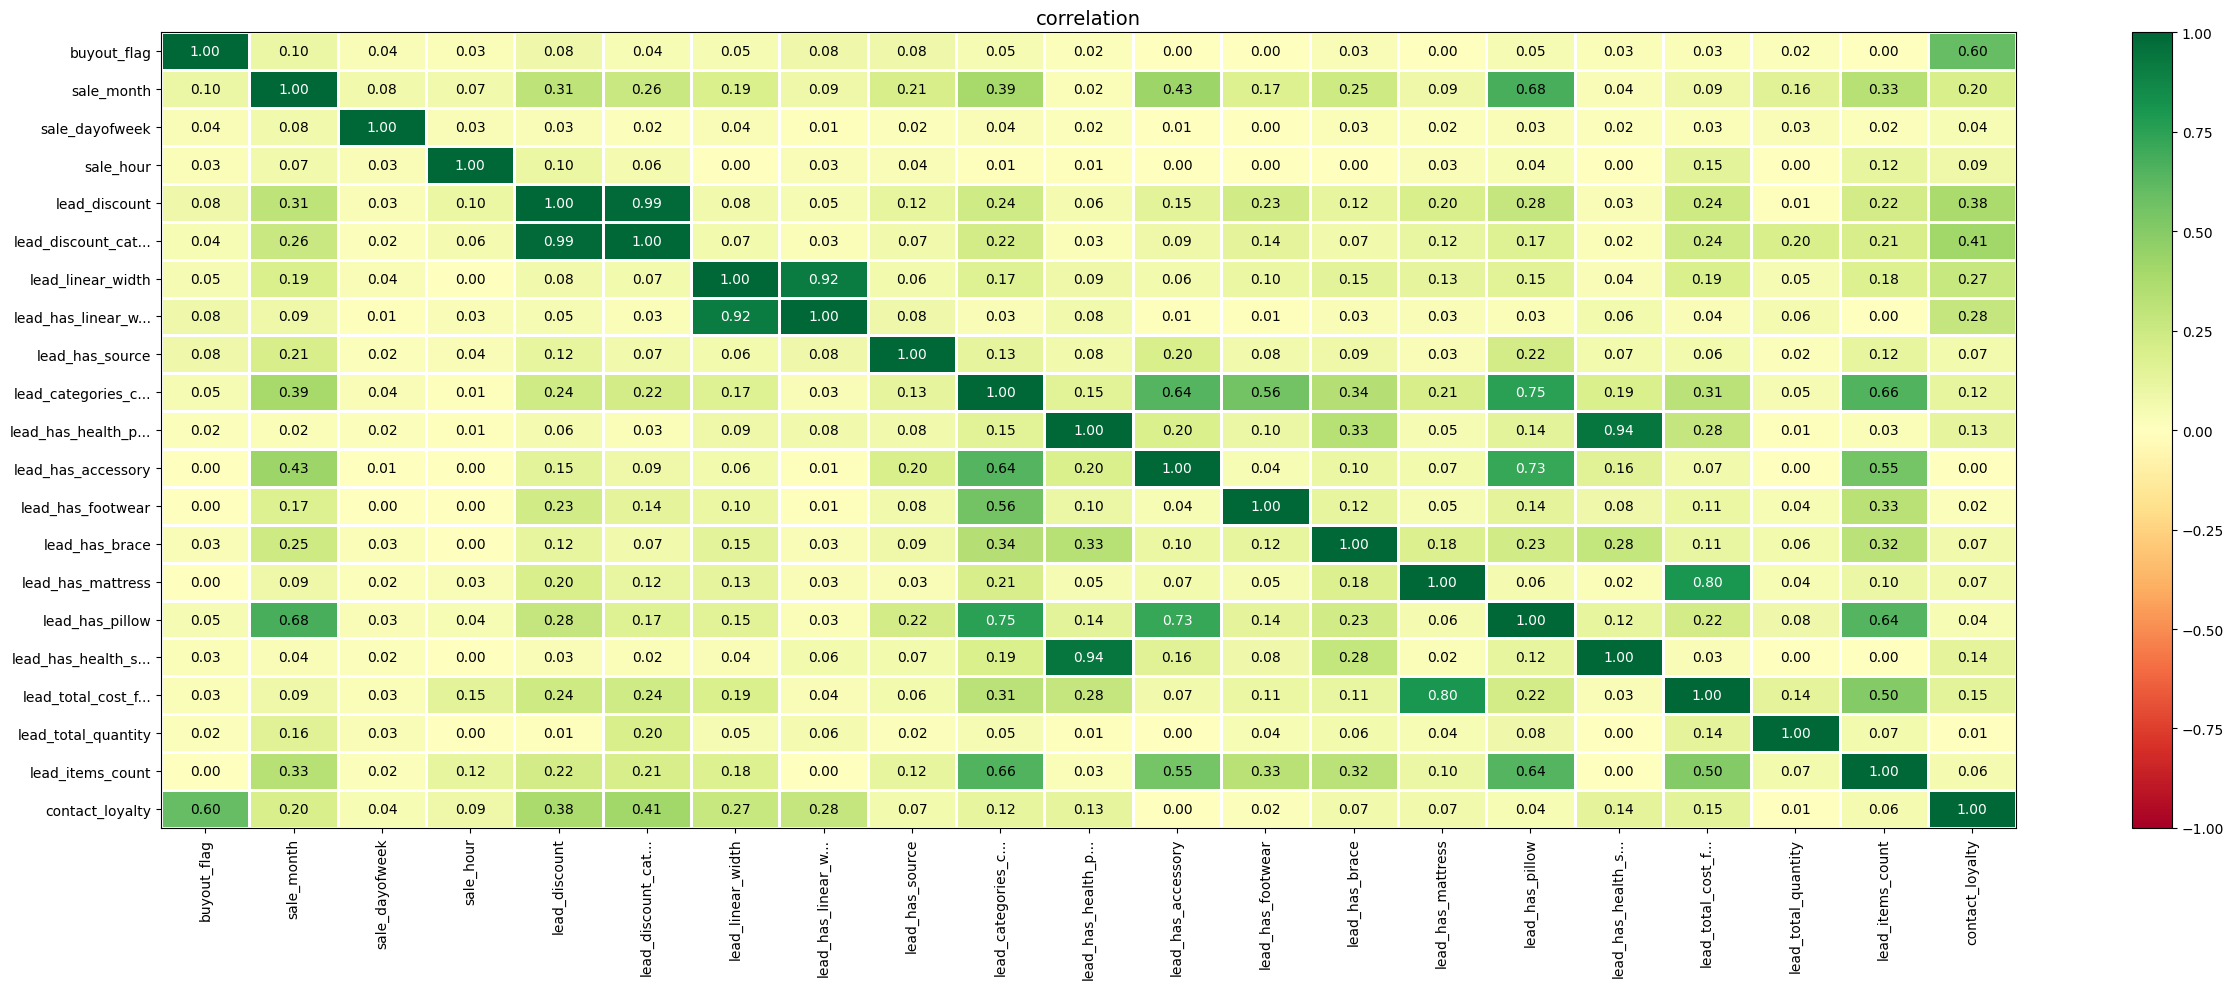

In [40]:
# Проверяем мультиколлинеарность
df_for_phik = X_block.copy()

df_for_phik['buyout_flag'] = my_full_copy['buyout_flag'].values

corr_matrix = phik_matrix(df_for_phik.drop(columns=[
    'sale_ts'
]))

plot_correlation_matrix(corr_matrix.values,
                        x_labels=corr_matrix.columns,
                        y_labels=corr_matrix.index,
                        figsize=(25, 10))

In [41]:
X_block.to_csv(OUTPUT_DIR / "X_block.csv", index=False)
# feature_spec = create_feature_spec_template(X_block)
# feature_spec.to_csv(OUTPUT_DIR / "feature_spec.csv", index=False)

print("Saved:")
print(OUTPUT_DIR / "X_block.csv")
# print(OUTPUT_DIR / "feature_spec.csv")

Saved:
../../notebook_outputs/group_4/X_block.csv
